<a href="https://colab.research.google.com/github/jumafernandez/ANN-UNSL/blob/main/notebooks/notebook_02_indexaci%C3%B3n_y_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧩 Notebook 2 — Indexación y evaluación de búsqueda aproximada (ANN)

En esta notebook trabajamos a partir de los embeddings generados en la Notebook 1.  
Nuestro objetivo es evaluar diferentes estrategias de *Approximate Nearest Neighbor Search* (ANN) usando **FAISS**, midiendo:

- **Recall@k**  
- **Queries Per Second (QPS)**  
- **Trade-off entre velocidad y precisión**  

Probamos distintas familias de métodos:

1. **Flat (búsqueda exacta)** — baseline obligatorio  
2. **IVF (Inverted File Index)**  
3. **IVF + PQ (Product Quantization)**  
4. **HNSW (grafo jerárquico small-world)**

Este análisis nos permitirá comparar cómo cada técnica escala con el tamaño del corpus y con la dimensionalidad de los vectores.


In [ ]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 34.5 MB/s eta 0:00:00


## 1. Recuperación de información

A continuación recuperamos los ids de los embeddings, los embeddings y el dataset generado en la notebook 01.

In [ ]:
import gdown
import numpy as np

Para facilitar los experimentos, se cargaron los embeddings generados mediante `all-mpnet-base-v2` y `all-MiniLM-L6-v2` en un repositorio de Google Drive y se permite parametrizar la notebook de acuerdo a la ejecución que se desea realizar:

In [ ]:
# EMBEDDING_EXPERIMENTO = 'all-mpnet-base-v2'
EMBEDDING_EXPERIMENTO = 'all-MiniLM-L6-v2'

# Embeddings `all-mpnet-base-v2`
id_embeddings = "13OWNpaWYT0nQKUtnb4LeLWvQEgCOEIkL"

if EMBEDDING_EXPERIMENTO == 'all-MiniLM-L6-v2':
  # Embeddings `all-MiniLM-L6-v2`
  id_embeddings = "1x0zT0yxQ93MN1B31BLVo8vIkOT5XbFaA"

# Ids de los embeddings
id_ids = "1Pa9MU4MFJZEJWiaff7xaCBeGSR8UGFYD"

# Dataset para generar la replicabilidad
id_dataset = "118WIMyxlJ3VksRY0q9cal8Z_76BzwoDy"

In [ ]:
# Descarga de archivos
gdown.download(f"https://drive.google.com/uc?id={id_ids}", "ids.npy", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={id_embeddings}", "embeddings.npy", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={id_dataset}", "multiwoz_turns.pkl", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Pa9MU4MFJZEJWiaff7xaCBeGSR8UGFYD
To: /content/ids.npy
100%|██████████| 1.14M/1.14M [00:00<00:00, 51.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1x0zT0yxQ93MN1B31BLVo8vIkOT5XbFaA
From (redirected): https://drive.google.com/uc?id=1x0zT0yxQ93MN1B31BLVo8vIkOT5XbFaA&confirm=t&uuid=f040d214-8f33-4eae-8521-05f58aba929c
To: /content/embeddings.npy
100%|██████████| 220M/220M [00:05<00:00, 36.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=118WIMyxlJ3VksRY0q9cal8Z_76BzwoDy
To: /content/multiwoz_turns.pkl
100%|██████████| 14.2M/14.2M [00:00<00:00, 29.6MB/s]


'multiwoz_turns.pkl'

In [ ]:
# Carga de arrays
ids = np.load("ids.npy")
embeddings = np.load("embeddings.npy")

In [ ]:
ids.shape, embeddings.shape

((143044,), (143044, 384))

In [ ]:
import pandas as pd

# Cargar el dataset unificado generado en la Notebook 01
df = pd.read_pickle("multiwoz_turns.pkl")

df.shape

(143044, 5)

In [ ]:
df.head()

,dialogue_id,split,turn_id,speaker,utterance
0,SSNG0169.json,train,0,USER,I am looking for a restaurant called the Gandhi.
1,SSNG0169.json,train,1,SYSTEM,The Gandhi is at 72 Regent Street City Centre....
2,SSNG0169.json,train,2,USER,I'd like a reservation for 7 people Monday at ...
3,SSNG0169.json,train,3,SYSTEM,Unable to book at that time.Would you like a d...
4,SNG0587.json,train,0,USER,I want crossover food at an expensive price. C...


### Registro sistemático de benchmarks

Para analizar el rendimiento de los distintos métodos de búsqueda aproximada (ANN)
es fundamental registrar los resultados de cada experimento en una estructura organizada.

Usamos una lista de diccionarios (`list[dict]`) donde cada diccionario almacena:

- tipo de índice (Flat, IVF…)
- parámetros (por ej. `nprobe`)
- tiempo de búsqueda
- recall@k
- información del dataset
- texto de la consulta (opc.)

Luego convertimos todo a un `DataFrame` para su análisis y exportación.

Esto permite:
- reproducibilidad
- generación automática de tablas y gráficos
- reportes para papers o presentaciones


In [ ]:
# Lista global donde guardamos todos los benchmarks
results = []

def log_result(index_type, params, k, time_ms, recall, extra=None):
    """
    Registra un resultado de benchmark en la lista global `results`.

    Parámetros
    ----------
    index_type : str
        Tipo de índice utilizado (ej: "FlatL2", "IVF", "HNSW", "PQ", etc.)

    params : dict
        Diccionario con los parámetros relevantes del índice.
        Ejemplo:
            {"nlist": 100, "nprobe": 10}
            {"efSearch": 32}
            {}

    k : int
        Cantidad de vecinos recuperados (k-NN).

    time_ms : float
        Tiempo total de búsqueda en milisegundos.

    recall : float
        Recall@k comparado contra la búsqueda exacta.
        Para índices exactos (FlatL2) → 1.0

    extra : dict | None
        Información adicional opcional (texto de la consulta, notas, etc.).

    Efecto
    ------
    Agrega un diccionario con todos los datos al listado global `results`.
    """

    entry = {
        "index_type": index_type,
        "params": params,
        "k": k,
        "time_ms": time_ms,
        "recall": recall,
        "num_vectors": embeddings.shape[0],
        "dimension": embeddings.shape[1],
    }

    if extra is not None:
        entry.update(extra)

    results.append(entry)

In [ ]:
def compute_recall(indices_exact, indices_test, k):
    """
    Calcula el recall@k comparando los vecinos exactos con los vecinos recuperados
    por un método aproximado (IVF, HNSW, PQ, etc.).

    Parámetros
    ----------
    indices_exact : array-like, shape (1, K_exact)
        Vecinos exactos obtenidos con un índice exacto (IndexFlatL2).

    indices_test : array-like, shape (1, K_test)
        Vecinos recuperados por el índice aproximado.

    k : int
        k para el cálculo de recall@k. Puede ser menor o igual al tamaño
        devuelto por ambos índices.

    Returns
    -------
    float
        Recall@k en rango [0, 1].
    """

    # Convertimos a sets y truncamos al top-k
    true_neighbors = set(indices_exact[0][:k])
    test_neighbors = set(indices_test[0][:k])

    # Intersección
    matches = len(true_neighbors.intersection(test_neighbors))

    # Cálculo del recall@k
    recall = matches / k

    return recall

## 2. Evaluación de diferentes técnicas de búsqueda

A continuación implementamos las diferentes técnicas de búsqueda.

En primer lugar cargamos el modelo y realizamos el embedding de la consulta que vamos a ejecutar sobre las diferentes estrategias de búsqueda:

In [ ]:
from sentence_transformers import SentenceTransformer

# Cargar el modelo deseado para realizar el embedding de la consulta
model_name = f"sentence-transformers/{EMBEDDING_EXPERIMENTO}"
model = SentenceTransformer(model_name)

print("Modelo cargado:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado: sentence-transformers/all-MiniLM-L6-v2


Definimos el query a utilizar para la búsqueda de embeddings:

In [ ]:
query = "I need to book a restaurant tonight for two people."

Generamos el embedding del query:

In [ ]:
# Generar embedding de la consulta (usar mismo modelo)
query_emb = model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")

In [ ]:
query_emb

array([[ 3.25249508e-02, -4.36187945e-02, -1.00657651e-02,
         5.10801226e-02, -1.94223031e-01,  4.89991233e-02,
        -4.29800972e-02, -6.50784746e-02, -1.78417861e-02,
        -6.53045326e-02,  4.70071808e-02,  3.31197605e-02,
        -3.15227620e-02, -1.99578628e-02,  1.11053409e-02,
        -1.05088785e-01,  8.43624398e-02,  5.36431409e-02,
         8.18504840e-02, -2.11447421e-02,  8.81869905e-03,
        -1.75343044e-02, -5.52746430e-02, -2.69612502e-02,
        -2.63591986e-02, -3.65736857e-02, -1.94982551e-02,
        -9.52184107e-03, -3.36714648e-02, -2.42722295e-02,
        -3.50072794e-02, -4.17644270e-02,  2.59794686e-02,
         1.80619378e-02, -2.61083320e-02, -2.33505722e-02,
         1.00042522e-01, -3.37737910e-02,  7.74090961e-02,
         1.68105718e-02, -8.57948326e-03, -8.04116111e-03,
        -3.45291980e-02, -8.95300414e-03,  1.48010822e-02,
         5.25919115e-03, -1.02512866e-01,  2.46792454e-02,
         7.97572955e-02,  9.05143544e-02, -4.02513593e-0

## 1. Construcción del índice FAISS: búsqueda **exacta** con `IndexFlatL2`

Comenzamos evaluando el método más simple y a la vez más importante:  
un índice **exacto** basado en distancia Euclidea (L2).

### ¿Qué es `IndexFlatL2`?
Es un índice *no estructurado* que almacena todos los embeddings en una matriz
y, ante cada consulta, compara contra **los 143.044 vectores** del dataset.
No realiza podas, ni particiones, ni aproximaciones:  
la búsqueda es completamente exhaustiva.

### ¿Por qué empezamos con este índice?
Porque funciona como **baseline absoluto**:

- garantiza el resultado correcto (vecinos reales);
- sirve para validar que los embeddings están correctos;
- nos permite medir el costo de la búsqueda exacta;
- establece el estándar contra el cual compararemos los métodos aproximados
  (IVF, HNSW, PQ, etc.).

En otras palabras:  
> *IndexFlatL2 nos dice cuán caro es hacer “lo correcto” sin usar ANN.*

### ¿Qué esperamos observar?
- Tiempos de búsqueda más altos que los métodos aproximados.  
- Resultados 100% precisos (Recall@k = 1).  
- Dependencia lineal con la cantidad de vectores (O(n · d)).

In [ ]:
import faiss

d = embeddings.shape[1]  # dimensión (ej: 768)

index_flat = faiss.IndexFlatL2(d)
index_flat.add(embeddings)

print("Total vectors:", index_flat.ntotal)

Total vectors: 143044


### Búsqueda: validación del índice FAISS

Antes de avanzar a métodos de búsqueda aproximada, realizamos una búsqueda simple para verificar que:

- el índice FAISS funciona correctamente,
- los embeddings recuperan textos semánticamente cercanos,
- la estructura de datos (ids + textos originales) está alineada.

Para esto:
3. Consultamos el índice `IndexFlatL2` para obtener los **k vecinos más
   cercanos**.
4. Recuperamos las oraciones originales según sus IDs.


In [ ]:
import time

# --- k vecinos más cercanos ---
k = 5

# --- Medición del tiempo ---
start = time.time()
distances, idx_exact = index_flat.search(query_emb, k)
end = time.time()

tiempo_ms = (end - start) * 1000
print(f"⏱️ Tiempo de búsqueda: {tiempo_ms:.4f} ms\n")

print("🔍 Resultados semánticamente similares (búsqueda exacta):\n")

for rank, idx in enumerate(idx_exact[0]):
    print(f"🔹 Rank {rank+1}")
    print(f"📝 Texto: {df.iloc[idx]['utterance']}")
    print(f"📏 Distancia L2: {distances[0][rank]:.4f}")
    print("—" * 50)

# === Registro en los benchmarks ===
log_result(
    index_type="FlatL2",
    params={},              # no tiene parámetros
    k=k,
    time_ms=tiempo_ms,
    recall=1.0,             # Flat es exacto → recall perfecto
    extra={"query_text": query}
)

print("\n📌 Resultado registrado en benchmarks.")

⏱️ Tiempo de búsqueda: 21.4374 ms

🔍 Resultados semánticamente similares (búsqueda exacta):

🔹 Rank 1
📝 Texto: i need a moderately priced hotel in south cambridge.
📏 Distancia L2: 0.2310
——————————————————————————————————————————————————
🔹 Rank 2
📝 Texto: Spanish food
📏 Distancia L2: 0.3333
——————————————————————————————————————————————————
🔹 Rank 3
📝 Texto: No that's all I needed. Thanks for your help.
📏 Distancia L2: 0.3456
——————————————————————————————————————————————————
🔹 Rank 4
📝 Texto: Yes please for 5 people for 5 nights from Monday please.
📏 Distancia L2: 0.3693
——————————————————————————————————————————————————
🔹 Rank 5
📝 Texto: Sure. Can you book it for 2 people on Saturday at 11:30?
📏 Distancia L2: 0.4371
——————————————————————————————————————————————————

📌 Resultado registrado en benchmarks.


## 2. Construcción de un índice FAISS IVF (Inverted File Index)

En esta sección construimos un índice de *búsqueda aproximada* utilizando  
**FAISS IndexIVFFlat**, una variante que reduce drásticamente el costo de búsqueda
comparado con `IndexFlatL2`.

A diferencia de la búsqueda exacta, IVF utiliza una estructura de listas invertidas:

1. **Clustering (nlist):**  
   Los embeddings se agrupan en `nlist` centroides (similar a k-means).

2. **Selección de listas relevantes (nprobe):**  
   Durante una búsqueda, FAISS identifica los `nprobe` centroides más cercanos
   al embedding de la consulta.

3. **Búsqueda dentro de esos centroides:**  
   Solo se comparan distancias con los vectores asignados a esos centroides,
   no con todo el dataset.

Esto genera búsquedas mucho más rápidas, especialmente cuando:

- el dataset es grande,
- el hardware es limitado,
- y necesitamos búsquedas interactivas o en tiempo real.

### 📌 Parámetros clave

- **`nlist`** — cantidad de listas (clusters):
  - valores altos → más precisión, mayor costo de entrenamiento, más RAM  
  - valores bajos → más rápido, menor precisión

- **`nprobe`** — cuántas listas inspeccionar durante la búsqueda:
  - valores bajos (1–4) → muy rápidos, menor recall  
  - valores altos (16–64+) → mejor recall, más costo de búsqueda

### 🎯 Objetivos de esta sección

Con este índice IVF vamos a:

- Entrenar el índice sobre nuestros 143k embeddings.
- Construir una estructura que permita experimentos con *velocidad vs precisión*.
- Testear distintos valores de `nprobe`.
- Registrar los resultados en nuestro sistema de benchmarking.

A continuación, entrenamos el índice IVF usando nuestros embeddings.

In [ ]:
# --- Parámetro principal del índice IVF ---
dimension = embeddings.shape[1]
nlist = 256

# --- Quantizer: FlatL2 para medir distancias dentro de cada lista ---
quantizer = faiss.IndexFlatL2(dimension)

# --- Construcción del índice IVF ---
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist)

# --- Entrenamiento del índice (k-means sobre centroides) ---
print("🎯 Entrenando índice IVF...")
start = time.time()
index_ivf.train(embeddings)
print("Entrenado?:", index_ivf.is_trained)
end = time.time()
print(f"⏱️ Tiempo de entrenamiento: {(end - start):.2f} s")

# --- Carga de los vectores ---
index_ivf.add(embeddings)
print(f"📦 Vectores en el índice IVF: {index_ivf.ntotal}")


🎯 Entrenando índice IVF...
Entrenado?: True
⏱️ Tiempo de entrenamiento: 2.36 s
📦 Vectores en el índice IVF: 143044


In [ ]:
# ---------------------------
# Configurar nprobe
# ---------------------------
nprobe = 16
index_ivf.nprobe = nprobe
print(f"🔎 nprobe configurado en: {nprobe}\n")

# ---------------------------
# Búsqueda ANN
# ---------------------------
start = time.time()
dist_ivf, idx_ivf = index_ivf.search(query_emb, k)
end = time.time()

tiempo_ms_ivf = (end - start) * 1000
print(f"⏱️ Tiempo de búsqueda IVF: {tiempo_ms_ivf:.4f} ms\n")

# ---------------------------
# Cálculo de recall@k
# indices_exact viene del índice FlatL2
# ---------------------------
recall_ivf = compute_recall(idx_exact, idx_ivf, k)
print(f"📈 Recall@{k}: {recall_ivf:.4f}\n")

# ---------------------------
# Mostrar resultados
# ---------------------------
print("🔍 Resultados semánticamente similares (IVF):\n")
for rank, idx in enumerate(idx_ivf[0]):
    print(f"🔹 Rank {rank+1}")
    print(f"📝 Texto: {df.iloc[idx]['utterance']}")
    print(f"📏 Distancia L2: {dist_ivf[0][rank]:.4f}")
    print("—" * 50)

# ---------------------------
# Registro en los benchmarks
# ---------------------------
log_result(
    index_type="IVF",
    params={"nlist": nlist, "nprobe": nprobe},
    k=k,
    time_ms=tiempo_ms_ivf,
    recall=recall_ivf,
    extra={"query_text": query}
)

print("📝 Resultado registrado en benchmarks.\n")

🔎 nprobe configurado en: 16

⏱️ Tiempo de búsqueda IVF: 2.3544 ms

📈 Recall@5: 1.0000

🔍 Resultados semánticamente similares (IVF):

🔹 Rank 1
📝 Texto: i need a moderately priced hotel in south cambridge.
📏 Distancia L2: 0.2310
——————————————————————————————————————————————————
🔹 Rank 2
📝 Texto: Spanish food
📏 Distancia L2: 0.3333
——————————————————————————————————————————————————
🔹 Rank 3
📝 Texto: No that's all I needed. Thanks for your help.
📏 Distancia L2: 0.3456
——————————————————————————————————————————————————
🔹 Rank 4
📝 Texto: Yes please for 5 people for 5 nights from Monday please.
📏 Distancia L2: 0.3693
——————————————————————————————————————————————————
🔹 Rank 5
📝 Texto: Sure. Can you book it for 2 people on Saturday at 11:30?
📏 Distancia L2: 0.4371
——————————————————————————————————————————————————
📝 Resultado registrado en benchmarks.



## 3. Construcción de un índice FAISS HNSW (grafos navegables)

El índice **HNSW (Hierarchical Navigable Small World)** implementa un grafo navegable
para búsqueda aproximada extremadamente eficiente.  
Es uno de los métodos más usados en la práctica debido a su excelente balance entre:

- **latencia muy baja**
- **alto recall**
- **sin necesidad de entrenamiento**

Parámetros importantes:

- **M**: grado máximo del grafo. A mayor M → mejor recall, más memoria.
- **efConstruction**: precisión durante la construcción del grafo.
- **efSearch**: precisión durante la búsqueda.
  - Más alto → mejor recall, más tiempo.

Este índice se considera un baseline clásico en la literatura (Johnson et al. 2017, ANN-Benchmarks).
A continuación construimos un índice HNSWFlat y evaluamos su rendimiento.

In [ ]:
# ================================
#   Construcción del índice HNSW
# ================================
import faiss
import time
import numpy as np

d = embeddings.shape[1]   # dimensión (768)

# --- Parámetros HNSW ---
M = 32                # grado del grafo (default típico: 16 o 32)
ef_construction = 40  # precisión durante construcción
ef_search = 64        # precisión durante búsqueda

print("🧱 Construyendo índice HNSWFlat...")

# Crear índice HNSW (distancia L2)
index_hnsw = faiss.IndexHNSWFlat(d, M)
index_hnsw.hnsw.efConstruction = ef_construction

# --- Agregar embeddings ---
start = time.time()
index_hnsw.add(embeddings)
end = time.time()

print(f"📦 Vectores cargados: {index_hnsw.ntotal}")
print(f"⏱️ Tiempo de construcción: {(end - start):.2f} s")

# --- Configurar efSearch ---
index_hnsw.hnsw.efSearch = ef_search
print(f"🔍 efSearch configurado en: {ef_search}")

🧱 Construyendo índice HNSWFlat...
📦 Vectores cargados: 143044
⏱️ Tiempo de construcción: 32.92 s
🔍 efSearch configurado en: 64


In [ ]:
# ================================
#   Búsqueda + Benchmark
# ================================
k = 5

start = time.time()
dist_hnsw, idx_hnsw = index_hnsw.search(query_emb, k)
end = time.time()
tiempo_ms = (end - start) * 1000

# --- Calcular recall@k ---
recall = compute_recall(idx_exact, idx_hnsw, k)

print(f"\n⏱️ Tiempo de búsqueda HNSW: {tiempo_ms:.4f} ms")
print(f"✔️ Recall@{k}: {recall:.4f}\n")

# --- Mostrar resultados ---
print("🔎 Resultados semánticamente similares (HNSW):\n")
for rank, idx in enumerate(idx_hnsw[0]):
    print(f"🔹 Rank {rank+1}")
    print(f"📝 Texto: {df.iloc[idx]['utterance']}")
    print(f"📏 Distancia L2: {dist_hnsw[0][rank]:.4f}")
    print("—" * 50)

# ================================
#   Logging del benchmark
# ================================
log_result(
    index_type="HNSW",
    params={
        "M": M,
        "efConstruction": ef_construction,
        "efSearch": ef_search
    },
    k=k,
    time_ms=tiempo_ms,
    recall=recall,
    extra={"query_text": query}
)

print("\n📄 Resultado registrado en benchmarks.\n")


⏱️ Tiempo de búsqueda HNSW: 1.0839 ms
✔️ Recall@5: 1.0000

🔎 Resultados semánticamente similares (HNSW):

🔹 Rank 1
📝 Texto: i need a moderately priced hotel in south cambridge.
📏 Distancia L2: 0.2310
——————————————————————————————————————————————————
🔹 Rank 2
📝 Texto: Spanish food
📏 Distancia L2: 0.3333
——————————————————————————————————————————————————
🔹 Rank 3
📝 Texto: No that's all I needed. Thanks for your help.
📏 Distancia L2: 0.3456
——————————————————————————————————————————————————
🔹 Rank 4
📝 Texto: Yes please for 5 people for 5 nights from Monday please.
📏 Distancia L2: 0.3693
——————————————————————————————————————————————————
🔹 Rank 5
📝 Texto: Sure. Can you book it for 2 people on Saturday at 11:30?
📏 Distancia L2: 0.4371
——————————————————————————————————————————————————

📄 Resultado registrado en benchmarks.



## 4. Índice FAISS IVFPQ (Inverted File + Product Quantization)

En esta sección combinamos dos ideas clave de FAISS:

1. **IVF (Inverted File Index)**  
   - Agrupa los embeddings en `nlist` centroides (clusters).
   - Durante la búsqueda, solo explora los `nprobe` centroides más cercanos al query.

2. **PQ (Product Quantization)**  
   - Divide cada embedding en `m` sub-vectores.
   - Cada sub-vector se cuantiza usando `nbits` bits.
   - En lugar de almacenar el vector completo en `float32`, se guarda solo su código cuantizado.
   - Esto reduce drásticamente la memoria: permite almacenar millones de embeddings en RAM.

El índice **IVFPQ** es uno de los más usados en la práctica para búsqueda aproximada a gran escala, porque ofrece un buen compromiso entre:

- **uso de memoria**
- **velocidad de búsqueda**
- **calidad de los vecinos recuperados (recall)**

### Parámetros principales

- **`nlist`**: número de centroides del IVF.  
  - Más centroides → mayor precisión, mayor costo de entrenamiento y memoria.
- **`m`**: número de sub-vectores en los que se divide cada embedding.  
  - Debe cumplir que la dimensión `d` sea divisible por `m`.
- **`nbits`**: bits por sub-vector.  
  - Con `nbits = 8`, cada sub-vector se representa con 1 byte.
- **`nprobe`**: cantidad de listas visitadas durante la búsqueda.  
  - Similar a IVF-Flat: valores mayores → mejor recall, más tiempo.

En el resto de esta sección:

- Entrenamos un índice **IVFPQ** sobre nuestros embeddings.
- Realizamos búsquedas aproximadas para una consulta fija.
- Comparamos su **tiempo de búsqueda** y **recall@k** contra:
  - la búsqueda exacta (`IndexFlatL2`)
  - el índice IVF-Flat
  - el índice HNSW

In [ ]:
# ==========================================
# 1. Construcción del índice IVFPQ
# ==========================================

import faiss
import time

d = embeddings.shape[1]

# --- Parámetros del IVF-PQ ---
nlist = 256     # número de centroides (clusters)
m = 32          # número de sub-vectores para PQ (requisito: d % m == 0)
nbits = 8       # bits por sub-vector (8 = 1 byte)

assert d % m == 0, "❌ d debe ser divisible por m para PQ"

print(f"🧱 Construyendo IVFPQ (nlist={nlist}, m={m}, nbits={nbits})...")

# --- Quantizer para IVF ---
quantizer_pq = faiss.IndexFlatL2(d)

# --- Construcción del índice ---
index_pq = faiss.IndexIVFPQ(quantizer_pq, d, nlist, m, nbits)

# --- Entrenamiento ---
print("🎯 Entrenando IVFPQ (esto puede tardar)...")
start = time.time()
index_pq.train(embeddings)
end = time.time()

print(f"⏱️ Tiempo de entrenamiento: {(end - start):.2f} s")

# --- Carga de vectores ---
index_pq.add(embeddings)
print(f"📦 Vectores en el índice: {index_pq.ntotal}")

🧱 Construyendo IVFPQ (nlist=256, m=32, nbits=8)...
🎯 Entrenando IVFPQ (esto puede tardar)...
⏱️ Tiempo de entrenamiento: 13.44 s
📦 Vectores en el índice: 143044


In [ ]:
# ==========================================
# 2. Búsqueda en IVFPQ
# ==========================================

k = 5
nprobe = 16

index_pq.nprobe = nprobe
print(f"🔍 nprobe configurado en: {nprobe}")

start = time.time()
dist_pq, idx_pq = index_pq.search(query_emb, k)
end = time.time()

tiempo_ms = (end - start) * 1000

# Calcular recall comparando con resultados exactos (IndexFlatL2)
recall = compute_recall(idx_exact, idx_pq, k)

print(f"\n⏱️ Tiempo de búsqueda IVFPQ: {tiempo_ms:.4f} ms")
print(f"✔️ Recall@{k}: {recall:.4f}\n")

print("🔎 Resultados semánticamente similares (IVFPQ):\n")
for rank, idx in enumerate(idx_pq[0]):
    print(f"🔹 Rank {rank+1}")
    print(f"📝 Texto: {df.iloc[idx]['utterance']}")
    print(f"📏 Distancia L2: {dist_pq[0][rank]:.4f}")
    print("—"*50)

# --- Logging ---
log_result(
    index_type="IVFPQ",
    params={"nlist": nlist, "m": m, "nbits": nbits, "nprobe": nprobe},
    k=k,
    time_ms=tiempo_ms,
    recall=recall,
    extra={"query_text": query}
)

print("\n📄 Resultado registrado en benchmarks.\n")

🔍 nprobe configurado en: 16

⏱️ Tiempo de búsqueda IVFPQ: 1.1630 ms
✔️ Recall@5: 0.8000

🔎 Resultados semánticamente similares (IVFPQ):

🔹 Rank 1
📝 Texto: i need a moderately priced hotel in south cambridge.
📏 Distancia L2: 0.3493
——————————————————————————————————————————————————
🔹 Rank 2
📝 Texto: No that's all I needed. Thanks for your help.
📏 Distancia L2: 0.3779
——————————————————————————————————————————————————
🔹 Rank 3
📝 Texto: Yes please for 5 people for 5 nights from Monday please.
📏 Distancia L2: 0.4390
——————————————————————————————————————————————————
🔹 Rank 4
📝 Texto: We have trains leaving every hour starting at 05:00 that day. What is your destination?
📏 Distancia L2: 0.4430
——————————————————————————————————————————————————
🔹 Rank 5
📝 Texto: Spanish food
📏 Distancia L2: 0.4562
——————————————————————————————————————————————————

📄 Resultado registrado en benchmarks.



## 4. Resultados experimentales

En esta sección analizamos cuantitativamente el desempeño de cada técnica de búsqueda:

- **FlatL2**: búsqueda exacta (baseline).
- **IVF**: índice invertido con listas (IndexIVFFlat).
- **HNSW**: grafo jerárquico navegable.
- **IVFPQ**: índice IVF con cuantización de producto.

Usamos dos métricas principales:

- ⏱️ **Tiempo de búsqueda** por consulta (en milisegundos).  
- 🎯 **Recall@k** comparado contra la búsqueda exacta (FlatL2), con el mismo valor de `k`.

A partir del registro sistemático en `results`, construimos un `DataFrame` para generar tablas y figuras.


In [ ]:
import pandas as pd

df_bench = pd.DataFrame(results)

df_bench


,index_type,params,k,time_ms,recall,num_vectors,dimension,query_text
0,FlatL2,{},5,21.437407,1.0,143044,384,I need to book a restaurant tonight for two pe...
1,IVF,"{'nlist': 256, 'nprobe': 16}",5,2.354383,1.0,143044,384,I need to book a restaurant tonight for two pe...
2,HNSW,"{'M': 32, 'efConstruction': 40, 'efSearch': 64}",5,1.083851,1.0,143044,384,I need to book a restaurant tonight for two pe...
3,IVFPQ,"{'nlist': 256, 'm': 32, 'nbits': 8, 'nprobe': 16}",5,1.163006,0.8,143044,384,I need to book a restaurant tonight for two pe...


## 🔧 Expansión de los parámetros del índice

Cada técnica tiene parámetros distintos (`nprobe`, `nlist`, `efSearch`, `m`, etc.).
Estos parámetros están almacenados en un diccionario.

Para analizarlos visualmente y generar gráficos comparativos, conviene expandirlos en columnas individuales.


In [ ]:
# Expandimos params en columnas
params_df = df_bench["params"].apply(pd.Series)
df_bench_expanded = pd.concat([df_bench.drop(columns=["params"]), params_df], axis=1)

df_bench_expanded

,index_type,k,time_ms,recall,num_vectors,dimension,query_text,nlist,nprobe,M,efConstruction,efSearch,m,nbits
0,FlatL2,5,21.437407,1.0,143044,384,I need to book a restaurant tonight for two pe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IVF,5,2.354383,1.0,143044,384,I need to book a restaurant tonight for two pe...,256.0,16.0,NaN,NaN,NaN,NaN,NaN
2,HNSW,5,1.083851,1.0,143044,384,I need to book a restaurant tonight for two pe...,NaN,NaN,32.0,40.0,64.0,NaN,NaN
3,IVFPQ,5,1.163006,0.8,143044,384,I need to book a restaurant tonight for two pe...,256.0,16.0,NaN,NaN,NaN,32.0,8.0


## ⏱️ Tiempo de búsqueda por técnica

Este gráfico compara el costo computacional de cada técnica.
Un menor tiempo implica una búsqueda más rápida.  
El índice FlatL2 es exacto pero lento; los métodos ANN aceleran la búsqueda a costa de
algo de precisión (recall).


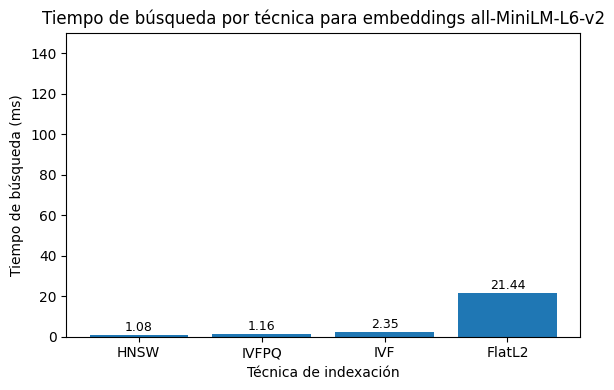

In [ ]:
import matplotlib.pyplot as plt

# (Opcional) ordenar por tiempo ascendente
df_time = df_bench_expanded.sort_values("time_ms")

plt.figure(figsize=(6,4))
plt.bar(df_time["index_type"], df_time["time_ms"])
plt.ylabel("Tiempo de búsqueda (ms)")
plt.xlabel("Técnica de indexación")
plt.title(f"Tiempo de búsqueda por técnica para embeddings {EMBEDDING_EXPERIMENTO}")
plt.ylim(0, 150) # Set y-axis limit from 0 to 65
plt.tick_params(top=False) # Remove the top horizontal line
for i, (x, y) in enumerate(zip(df_time["index_type"], df_time["time_ms"])):
    plt.text(i, y + 0.5, f"{y:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## ✔️ Recall@k por técnica

El recall mide cuántos de los vecinos obtenidos por el método aproximado coinciden con los vecinos
de la búsqueda exacta (FlatL2).  
Recall alto significa mayor precisión semántica; recall bajo indica pérdida de calidad.


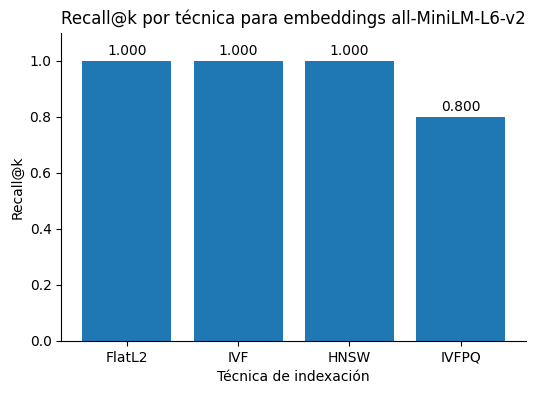

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

ax.bar(df_bench_expanded['index_type'], df_bench_expanded['recall'])

# Etiquetas
ax.set_xlabel("Técnica de indexación")
ax.set_ylabel("Recall@k")
ax.set_title(f"Recall@k por técnica para embeddings {EMBEDDING_EXPERIMENTO}")

# Mostrar valores arriba de cada barra
for i, v in enumerate(df_bench_expanded['recall']):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center')

# 🔥 Quitar la línea horizontal superior
ax.spines['top'].set_visible(False)

# (Opcional) también podés quitar la derecha, queda más estilo paper:
ax.spines['right'].set_visible(False)

plt.ylim(0, 1.1)
plt.show()


## 🎯 Trade-off entre tiempo de búsqueda y recall

En ANN siempre existe un equilibrio entre velocidad y precisión.
Este scatterplot muestra cómo se posiciona cada índice:

- Métodos rápidos → bajos tiempos
- Métodos precisos → alto recall

El objetivo es elegir la técnica que ofrezca mejor equilibrio según el caso de uso.


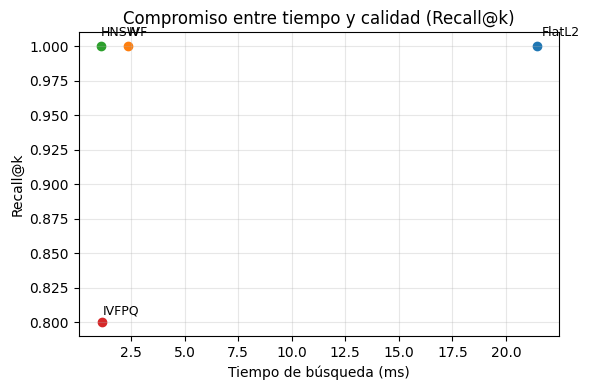

In [ ]:
plt.figure(figsize=(6,4))
for _, row in df_bench_expanded.iterrows():
    plt.scatter(row["time_ms"], row["recall"])
    plt.text(row["time_ms"]*1.01, row["recall"]*1.01, row["index_type"],
             fontsize=9, va="center")

plt.xlabel("Tiempo de búsqueda (ms)")
plt.ylabel("Recall@k")
plt.title("Compromiso entre tiempo y calidad (Recall@k)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 💾 Persistencia de resultados de experimentos

Por último, persistimos los resultados de los experimentos para realizar un análisis posterior:

In [ ]:
from google.colab import files

# Expandimos params en columnas
params_df = df_bench["params"].apply(pd.Series)
df_bench_expanded = pd.concat([df_bench.drop(columns=["params"]), params_df], axis=1)

# Agregamos el nombre del modelo de embeddings usado en esta corrida
df_bench_expanded["embedding_model"] = EMBEDDING_EXPERIMENTO

# Reordenamos columnas para que quede más prolijo
cols_base = ["embedding_model", "index_type", "k", "time_ms", "recall", "num_vectors", "dimension", "query_text"]
cols_existentes = [c for c in cols_base if c in df_bench_expanded.columns]
otras_cols = [c for c in df_bench_expanded.columns if c not in cols_existentes]
df_bench_expanded = df_bench_expanded[cols_existentes + otras_cols]

# Nombre del archivo de salida según el modelo
nombre_salida = f"ann_results_{EMBEDDING_EXPERIMENTO}.csv"

# Guardar CSV
df_bench_expanded.to_csv(nombre_salida, index=False, encoding="utf-8")
files.download(nombre_salida)

print(f"✅ Resultados exportados en: {nombre_salida}")
df_bench_expanded

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Resultados exportados en: ann_results_all-MiniLM-L6-v2.csv


,embedding_model,index_type,k,time_ms,recall,num_vectors,dimension,query_text,nlist,nprobe,M,efConstruction,efSearch,m,nbits
0,all-MiniLM-L6-v2,FlatL2,5,21.437407,1.0,143044,384,I need to book a restaurant tonight for two pe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,all-MiniLM-L6-v2,IVF,5,2.354383,1.0,143044,384,I need to book a restaurant tonight for two pe...,256.0,16.0,NaN,NaN,NaN,NaN,NaN
2,all-MiniLM-L6-v2,HNSW,5,1.083851,1.0,143044,384,I need to book a restaurant tonight for two pe...,NaN,NaN,32.0,40.0,64.0,NaN,NaN
3,all-MiniLM-L6-v2,IVFPQ,5,1.163006,0.8,143044,384,I need to book a restaurant tonight for two pe...,256.0,16.0,NaN,NaN,NaN,32.0,8.0
